# 🧠 Hybrid Models (ARIMA + LSTM & ETS + GRU)

**Goal:** Capture both linear patterns and non-linear residuals by combining statistical models (ARIMA, Auto-ETS) and deep learning models (LSTM, GRU).

## ✅ Step 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
import tensorflow as tf

warnings.filterwarnings('ignore')
print('✅ All imports successful')
print('GPU Available:', tf.config.list_physical_devices('GPU'))

✅ All imports successful
GPU Available: []


## ✅ Step 2: Load Preprocessed Data

In [2]:
train_df = pd.read_csv('data/processed/train_monthly.csv', parse_dates=['date'], index_col='date')
test_df  = pd.read_csv('data/processed/test_monthly.csv',  parse_dates=['date'], index_col='date')

train_df.index = pd.DatetimeIndex(train_df.index).to_period('M').to_timestamp('M')
test_df.index  = pd.DatetimeIndex(test_df.index).to_period('M').to_timestamp('M')

train = train_df['amount']
test  = test_df['amount']

print(f'📅 Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} months)')
print(f'📅 Test : {test.index[0].date()} → {test.index[-1].date()}   ({len(test)} months)')

📅 Train: 2020-01-31 → 2024-06-30  (54 months)
📅 Test : 2024-07-31 → 2024-12-31   (6 months)


## ✅ Step 3: Base Linear Models (ARIMA & ETS)

In [3]:
# 1. Fit ARIMA (d=0 based on ADF test from earlier analysis)
# We use p=1, d=0, q=1 as a general starting point
arima_model = ARIMA(train, order=(1, 0, 1))
arima_result = arima_model.fit()
arima_train_pred = arima_result.fittedvalues
arima_test_pred = arima_result.forecast(steps=len(test))

# Calculate ARIMA residuals on train
arima_residuals = train - arima_train_pred

# 2. Fit ETS (Exponential Smoothing)
ets_model = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method="estimated")
ets_result = ets_model.fit()
ets_train_pred = ets_result.fittedvalues
ets_test_pred = ets_result.forecast(steps=len(test))

# Calculate ETS residuals on train
ets_residuals = train - ets_train_pred

print("✅ Base models trained and residuals extracted")

✅ Base models trained and residuals extracted


## ✅ Step 4: Prepare Residuals for Neural Networks

In [4]:
def prepare_nn_data(series, n_steps):
    X, y = [], []
    for i in range(len(series)):
        end_ix = i + n_steps
        if end_ix > len(series)-1:
            break
        seq_x, seq_y = series[i:end_ix], series[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

n_steps = 3

# For ARIMA Residuals
scaler_arima = MinMaxScaler()
arima_res_scaled = scaler_arima.fit_transform(arima_residuals.values.reshape(-1, 1))

X_arima, y_arima = prepare_nn_data(arima_res_scaled, n_steps)
X_arima = X_arima.reshape((X_arima.shape[0], X_arima.shape[1], 1))

# For ETS Residuals
scaler_ets = MinMaxScaler()
ets_res_scaled = scaler_ets.fit_transform(ets_residuals.values.reshape(-1, 1))

X_ets, y_ets = prepare_nn_data(ets_res_scaled, n_steps)
X_ets = X_ets.reshape((X_ets.shape[0], X_ets.shape[1], 1))

print("✅ Residuals sequences prepared for deep learning")

✅ Residuals sequences prepared for deep learning


## ✅ Step 5: Fit LSTM on ARIMA Residuals

In [5]:
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(n_steps, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_arima, y_arima, epochs=50, verbose=0)

print("✅ LSTM model trained on ARIMA residuals")

✅ LSTM model trained on ARIMA residuals


## ✅ Step 6: Fit GRU on ETS Residuals

In [6]:
tf.random.set_seed(42)

gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(n_steps, 1)),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_ets, y_ets, epochs=50, verbose=0)

print("✅ GRU model trained on ETS residuals")

✅ GRU model trained on ETS residuals


## ✅ Step 7: Forecast & Combine (Hybrid Models)

In [7]:
# 1. Forecast residuals using LSTM (for ARIMA)
arima_res_history = list(arima_res_scaled[-n_steps:].flatten())
lstm_res_preds = []

for _ in range(len(test)):
    x_input = np.array(arima_res_history[-n_steps:]).reshape((1, n_steps, 1))
    yhat = lstm_model.predict(x_input, verbose=0)[0][0]
    lstm_res_preds.append(yhat)
    arima_res_history.append(yhat)

lstm_res_preds_inv = scaler_arima.inverse_transform(np.array(lstm_res_preds).reshape(-1, 1)).flatten()

# Hybrid 1 = ARIMA Forecast + LSTM Residual Forecast
hybrid_arima_lstm_pred = arima_test_pred.values + lstm_res_preds_inv

# 2. Forecast residuals using GRU (for ETS)
ets_res_history = list(ets_res_scaled[-n_steps:].flatten())
gru_res_preds = []

for _ in range(len(test)):
    x_input = np.array(ets_res_history[-n_steps:]).reshape((1, n_steps, 1))
    yhat = gru_model.predict(x_input, verbose=0)[0][0]
    gru_res_preds.append(yhat)
    ets_res_history.append(yhat)

gru_res_preds_inv = scaler_ets.inverse_transform(np.array(gru_res_preds).reshape(-1, 1)).flatten()

# Hybrid 2 = ETS Forecast + GRU Residual Forecast
hybrid_ets_gru_pred = ets_test_pred.values + gru_res_preds_inv

print("✅ Hybrid forecasts generated")

✅ Hybrid forecasts generated


## ✅ Step 8: Evaluation & Visualization

--- ARIMA Basic ---
MAE : 840.72
RMSE: 1012.84
MAPE: 50.17%

--- Hybrid (ARIMA + LSTM) ---
MAE : 771.43
RMSE: 934.29
MAPE: 49.25%

--- ETS Basic ---
MAE : 1197.87
RMSE: 1344.48
MAPE: 53.68%

--- Hybrid (ETS + GRU) ---
MAE : 1054.99
RMSE: 1212.24
MAPE: 49.22%



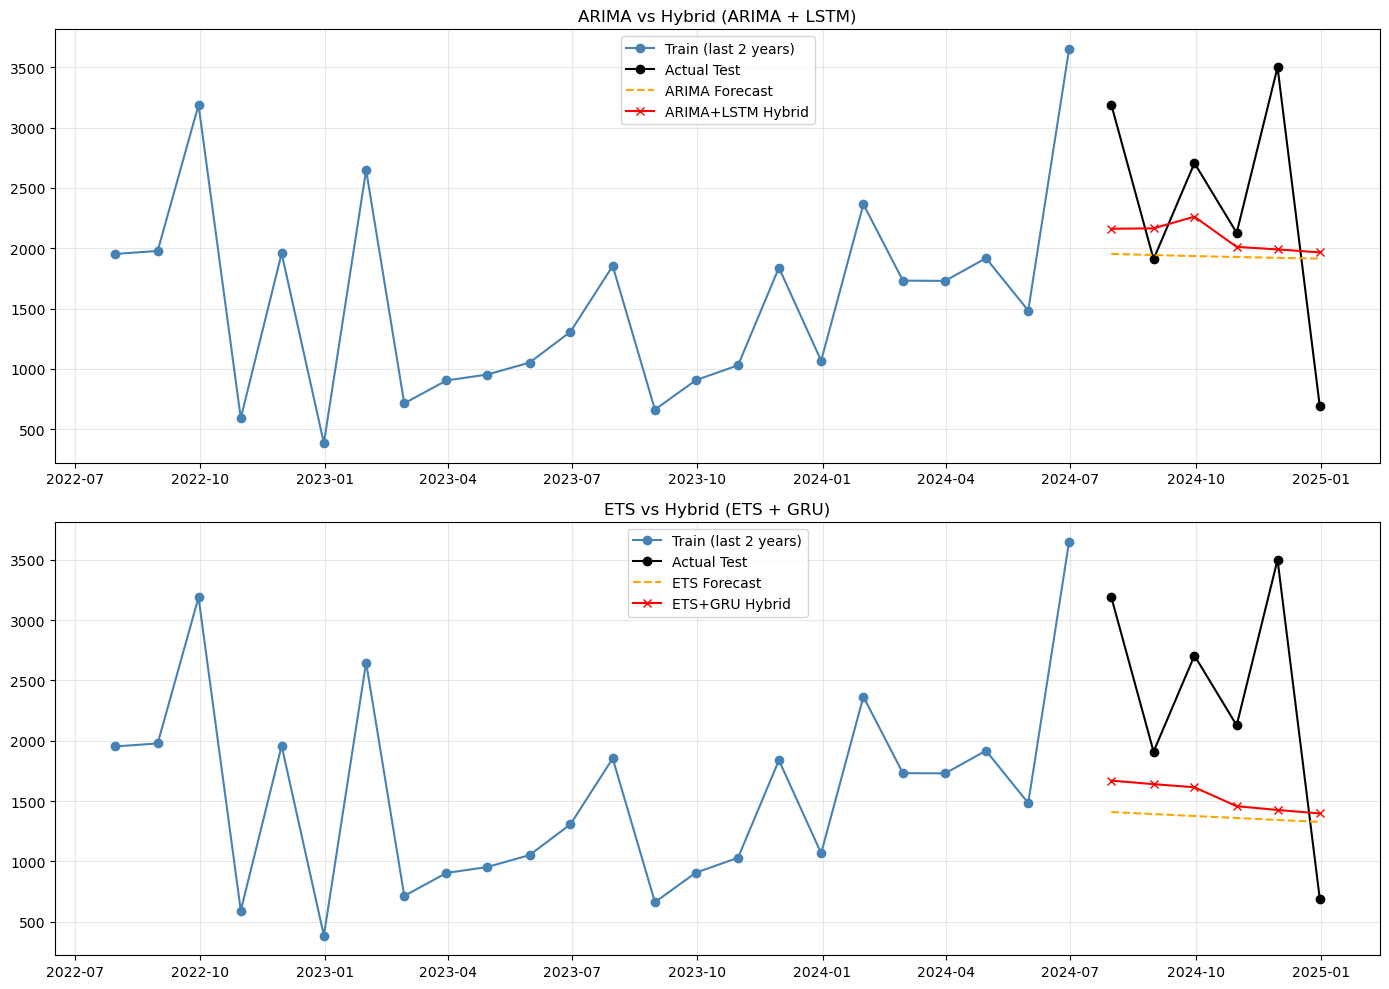

In [8]:
def evaluate_forecast(actual, pred, label):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"--- {label} ---")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%\n")

evaluate_forecast(test.values, arima_test_pred.values, "ARIMA Basic")
evaluate_forecast(test.values, hybrid_arima_lstm_pred, "Hybrid (ARIMA + LSTM)")

evaluate_forecast(test.values, ets_test_pred.values, "ETS Basic")
evaluate_forecast(test.values, hybrid_ets_gru_pred, "Hybrid (ETS + GRU)")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: ARIMA vs Hybrid
axes[0].plot(train.index[-24:], train.values[-24:], label='Train (last 2 years)', color='steelblue', marker='o')
axes[0].plot(test.index, test.values, label='Actual Test', color='black', marker='o')
axes[0].plot(test.index, arima_test_pred.values, label='ARIMA Forecast', color='orange', linestyle='--')
axes[0].plot(test.index, hybrid_arima_lstm_pred, label='ARIMA+LSTM Hybrid', color='red', marker='x')
axes[0].set_title('ARIMA vs Hybrid (ARIMA + LSTM)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: ETS vs Hybrid
axes[1].plot(train.index[-24:], train.values[-24:], label='Train (last 2 years)', color='steelblue', marker='o')
axes[1].plot(test.index, test.values, label='Actual Test', color='black', marker='o')
axes[1].plot(test.index, ets_test_pred.values, label='ETS Forecast', color='orange', linestyle='--')
axes[1].plot(test.index, hybrid_ets_gru_pred, label='ETS+GRU Hybrid', color='red', marker='x')
axes[1].set_title('ETS vs Hybrid (ETS + GRU)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ✅ Step 9: Save Trained Models

**Note:** We save the base models, the neural networks, and the scalers used for residuals to ensure we can perform future inference.

In [9]:
import os
import pickle

# Create models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Save statsmodels (ARIMA & ETS)
arima_result.save('models/arima_hybrid_base.pkl')
ets_result.save('models/ets_hybrid_base.pkl')

# 2. Save Keras models (LSTM & GRU)
lstm_model.save('models/lstm_arima_residuals.h5')
gru_model.save('models/gru_ets_residuals.h5')

# 3. Save Scalers (essential for inverse transform during inference)
with open('models/scaler_arima.pkl', 'wb') as f:
    pickle.dump(scaler_arima, f)

with open('models/scaler_ets.pkl', 'wb') as f:
    pickle.dump(scaler_ets, f)

print("✅ All models and scalers saved successfully in 'models/' directory.")

✅ All models and scalers saved successfully in 'models/' directory.
